In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [2]:
raw_data = pd.read_csv('data/Unicorn_Companies.csv')
raw_data.head()

,Company,Valuation,Date Joined,Industry,City,Country,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."


In [3]:
country_breakdown = raw_data.groupby(['Country', 'Industry']).count().reset_index()
country_breakdown = country_breakdown.replace('Artificial intelligence', 'Artificial Intelligence')
cb = country_breakdown[['Country', 'Company']].groupby('Country').sum().reset_index()
cb = cb.sort_values('Company', ascending=False)
cb.head()

,Country,Company
44,United States,562
9,China,173
19,India,65
43,United Kingdom,43
17,Germany,26


/var/folders/9f/33mp16f51m388dc_vf66f8_r0000gn/T/ipykernel_1024/3009972260.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(cb['Country'], rotation=45)


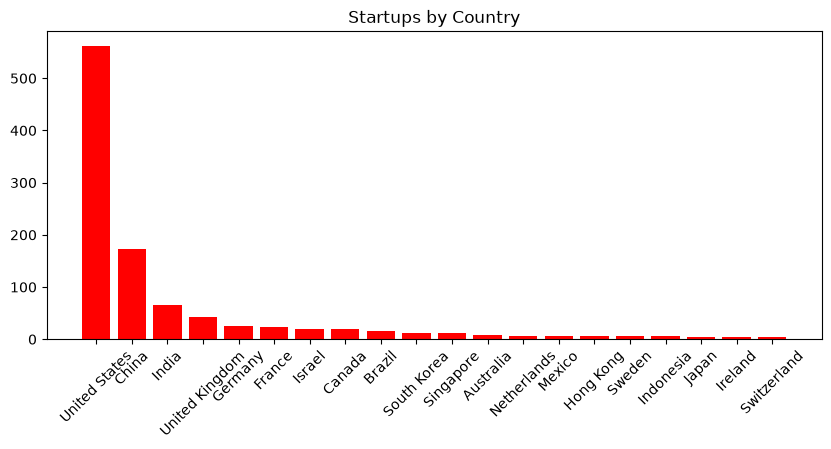

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.bar(cb['Country'][:20], cb['Company'][:20], color='red')
ax.set_title('Startups by Country')
ax.set_xticklabels(cb['Country'], rotation=45)
plt.show()

In [5]:
def valuation_conversion(val):

    if not isinstance(val, str):
        return val
    
    val = val.replace('$', '').strip()

    if val.endswith('B'):
        return int(float(val[:-1])*1_000_000_000)
    elif val.endswith('M'):
        return int(float(val[:-1]) * 1_000_000)
    elif val.endswith('K'):
        return int(float(val[:-1]) * 1_000)
    
    return int(float(val))

In [6]:
funding = raw_data[['Company', 'Industry', 'City', 'Country', 'Funding']]
funding = funding[funding['Funding'] != 'Unknown']
funding['Dollars_Funding'] = funding['Funding'].map(valuation_conversion)
funding.head()

,Company,Industry,City,Country,Funding,Dollars_Funding
0,Bytedance,Artificial intelligence,Beijing,China,$8B,8000000000
1,SpaceX,Other,Hawthorne,United States,$7B,7000000000
2,SHEIN,E-commerce & direct-to-consumer,Shenzhen,China,$2B,2000000000
3,Stripe,Fintech,San Francisco,United States,$2B,2000000000
4,Klarna,Fintech,Stockholm,Sweden,$4B,4000000000


In [7]:
total_funding = funding[['Country', 'Dollars_Funding', 'Company']].groupby('Country').agg(
    Dollars_Funding=('Dollars_Funding', 'sum'),
    Num_Companies = ('Company', 'count')
).reset_index().sort_values('Dollars_Funding', ascending=False)

tf_top20 = total_funding[:20]
tf_top20['Avg_Funding_Per_Company'] = (tf_top20['Dollars_Funding']/tf_top20['Num_Companies']).map('{:,.2f}'.format)
tf_top20['Dollars_Funding'] = tf_top20['Dollars_Funding'].map('{:,.2f}'.format)


/var/folders/9f/33mp16f51m388dc_vf66f8_r0000gn/T/ipykernel_1024/1346731009.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(tf_top20['Country'], rotation=45)


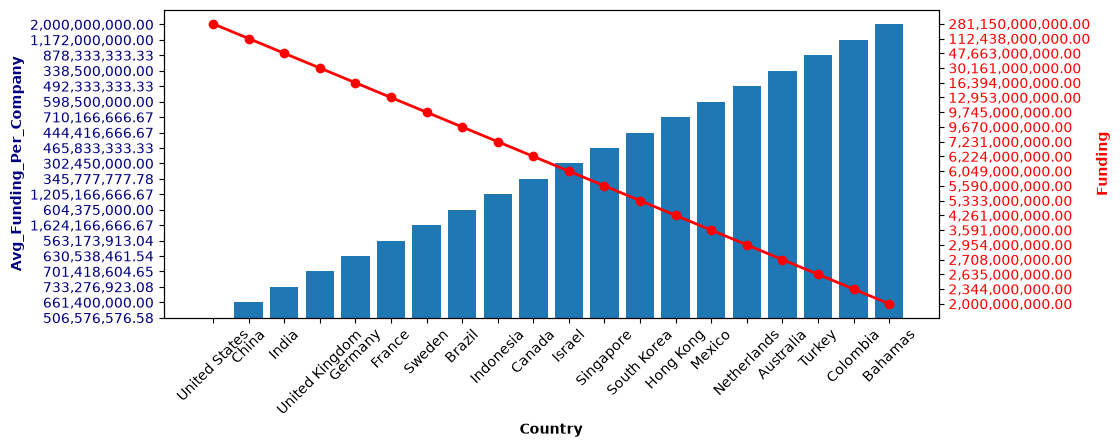

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10,4))
ax.set_xlabel('Country', fontweight='bold')
ax.set_ylabel('Avg_Funding_Per_Company', color='navy', fontweight='bold')

bars = ax.bar(tf_top20['Country'], tf_top20['Avg_Funding_Per_Company'])
ax.tick_params(axis='y', labelcolor='navy')
ax.set_xticklabels(tf_top20['Country'], rotation=45)

ax2=ax.twinx()
ax2.set_ylabel('Funding', color='red', fontweight='bold')
ax2.plot(tf_top20['Country'], tf_top20['Dollars_Funding'], color='red', marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor='red')
ax2.invert_yaxis()

plt.show()